# Projet Apprentissage Machine — Analyse des pays européens

## Description

Analyse de 27 pays européens à partir de 7 indicateurs socio-économiques.

**Variables** : espérance de vie, mortalité infantile, taux d'activité féminine, taux de chômage, PNB par habitant, dépenses en éducation et dépenses en santé.

**Source** : Binome7/pays.txt

## Imports

In [1]:
import sys
sys.path.insert(0, "..")

from scipy.stats import skew, kurtosis

from src.load_data import load_data
from src.preprocessing import normalize, run_pca, compute_contributions
from src.eda import (plot_histbox, show_outliers, plot_correlation, plot_pairplot,
                     plot_screeplot, plot_contributions, plot_cercle,
                     plot_plan_factoriel, plot_clusters)
from src.clustering import run_cah, compute_silhouette, plot_silhouette, run_kmeans

## Load Data

In [2]:
df = load_data("../data/pays.txt")
df.head()

,esp_vie_F,mort_inf,activ_F,chom,pnb_hb,education,sante
pays,,,,,,,
Allemagne,74.8,4.4,48.8,8.2,26768.0,4.3,10.6
Autriche,75.4,4.8,49.0,4.1,29075.0,4.9,8.0
Belgique,75.1,5.0,42.3,7.3,27952.0,5.8,8.8
Chypre,75.3,5.6,50.9,3.8,12724.0,5.8,6.0
Danemark,74.5,5.3,73.8,4.5,30096.0,8.1,8.4


## Data First Insights

In [3]:
# Check the number of rows and columns
df.shape

(27, 7)

In [4]:
# Check dataset structure and data types
df.info()

<class 'pandas.DataFrame'>
Index: 27 entries, Allemagne to Tchéquie
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   esp_vie_F  27 non-null     float64
 1   mort_inf   27 non-null     float64
 2   activ_F    27 non-null     float64
 3   chom       27 non-null     float64
 4   pnb_hb     27 non-null     float64
 5   education  27 non-null     float64
 6   sante      27 non-null     float64
dtypes: float64(7)
memory usage: 1.9 KB


In [5]:
# Count missing values in each column
df.isna().sum()

esp_vie_F    0
mort_inf     0
activ_F      0
chom         0
pnb_hb       0
education    0
sante        0
dtype: int64

In [6]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

## Initial Data Exploration

### 1. Dataset Overview

Le jeu de données contient **27 observations** (pays européens) décrites par **7 variables** quantitatives continues, toutes de type `float64`. Il n'y a aucune variable qualitative ni variable cible — ce qui pourrait nous orienter vers une approche de **clustering** pour découvrir la structure cachée des données.

### 2. Data Structure Analysis

**Float columns (7) :**
- `esp_vie_F` : espérance de vie des femmes (années)
- `mort_inf` : mortalité infantile (‰)
- `activ_F` : taux d'activité féminine (%)
- `chom` : taux de chômage (%)
- `pnb_hb` : PNB par habitant ($)
- `education` : dépenses d'éducation (% du PNB)
- `sante` : dépenses de santé (% du PNB)

### 3. Missing Value Analysis

Aucune valeur manquante détectée. Aucun traitement d'imputation n'est nécessaire.

### 4. Data Quality Issues

Aucun doublon détecté. Les données sont complètes et prêtes pour l'analyse.

## Exploratory Data Analysis (EDA)

### Statistiques Univariées

Pour chaque variable, on analyse la tendance centrale, la dispersion et la forme de la distribution.

In [7]:
# Statistical summary of the dataset
desc = df.describe()
desc.loc["skewness"] = df.apply(skew)
desc.loc["kurtosis"] = df.apply(kurtosis)
desc.round(2)

,esp_vie_F,mort_inf,activ_F,chom,pnb_hb,education,sante
count,27.00,27.00,27.00,27.00,27.00,27.00,27.00
mean,73.31,5.79,50.65,7.65,22380.22,5.36,7.54
std,3.70,1.86,10.98,4.01,10288.31,1.16,1.63
min,64.50,3.40,22.90,2.40,7809.00,2.30,4.20
25%,72.25,4.55,46.55,4.45,12728.50,4.65,6.25
50%,75.00,5.30,50.90,7.40,26756.00,5.20,7.90
75%,75.50,6.05,53.55,9.45,28513.50,5.75,8.45
max,77.50,10.40,76.20,18.10,50410.00,8.10,10.70
skewness,-1.22,0.98,0.21,0.98,0.49,0.13,-0.09
kurtosis,0.37,-0.06,1.20,0.76,0.13,1.11,-0.45


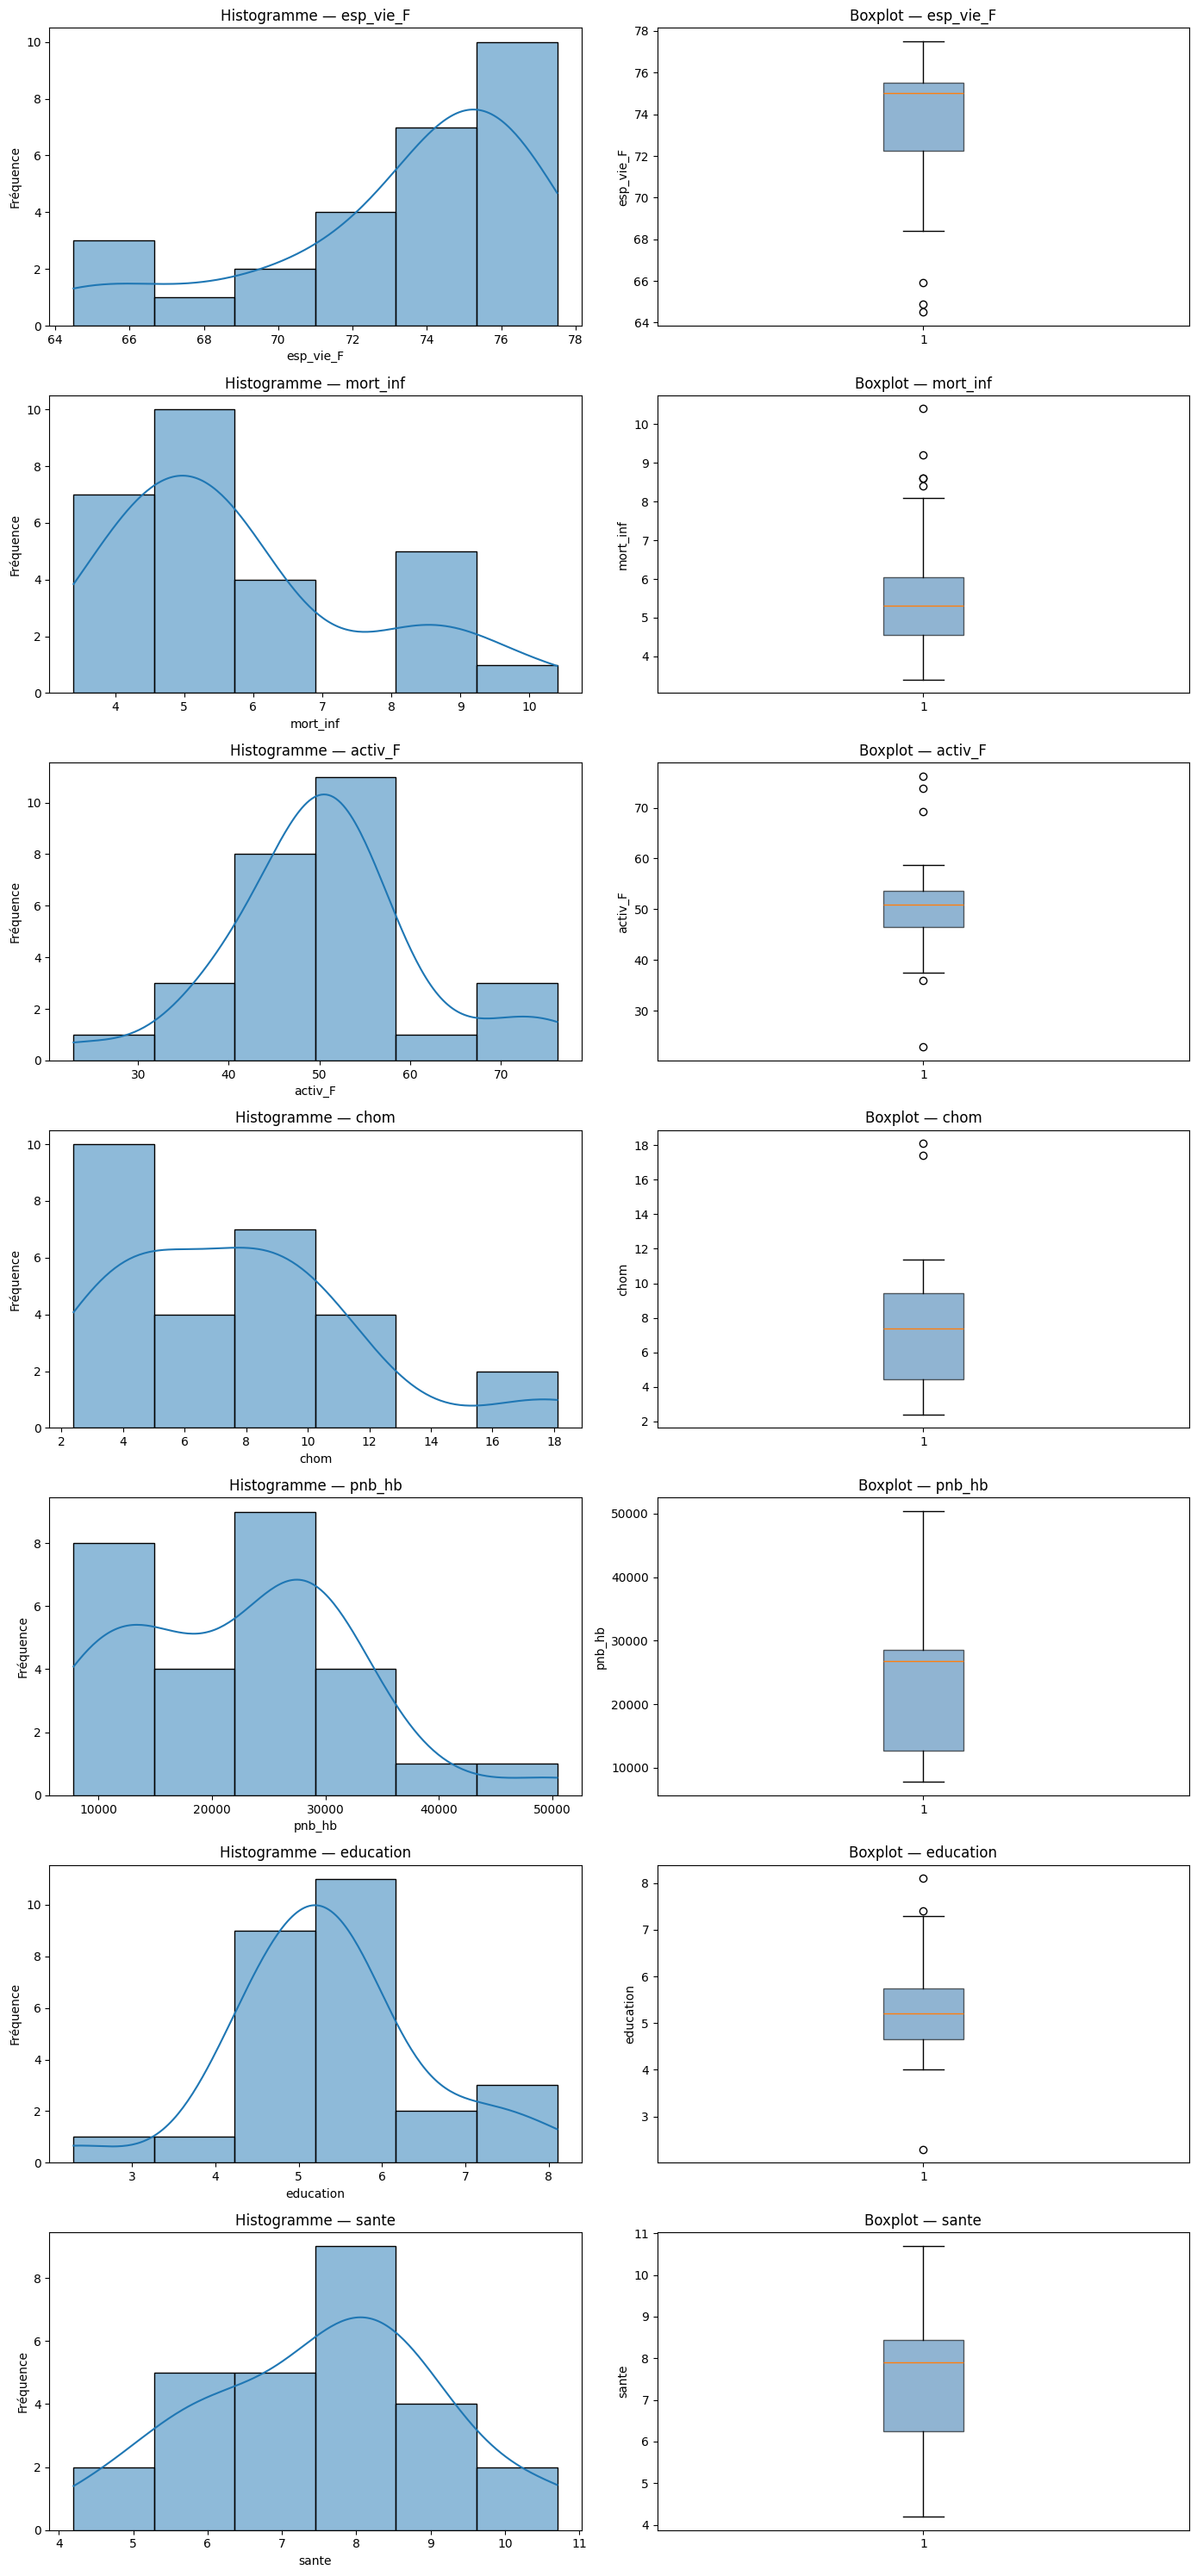

In [8]:
plot_histbox(df)

Pour une identification précise des outliers, nous utilisons la méthode de l'**intervalle interquartile (IQR)**  :

- **Seuil bas** = Q1 - 1.5 × IQR
- **Seuil haut** = Q3 + 1.5 × IQR

Toute valeur en dehors de ces seuils est considérée comme un **outlier**.

In [9]:
show_outliers(df)

esp_vie_F: ['Estonie', 'Lettonie', 'Lituanie'] - valeurs: [64.9, 64.5, 65.9]
mort_inf: ['Estonie', 'Hongrie', 'Lettonie', 'Lituanie', 'Slovaquie'] - valeurs: [8.4, 9.2, 10.4, 8.6, 8.6]
activ_F: ['Danemark', 'Italie', 'Malte', 'Norvège', 'Suède'] - valeurs: [73.8, 36.0, 22.9, 69.2, 76.2]
chom: ['Pologne', 'Slovaquie'] - valeurs: [18.1, 17.4]
education: ['Danemark', 'Grèce', 'Norvège'] - valeurs: [8.1, 2.3, 7.4]


## Interprétation des statistiques descriptives

### 1. Analyse des variables

**`esp_vie_F` : Espérance de vie des femmes**
- Distribution **asymétrique à gauche** (skewness = -1.22) : la majorité des pays ont une espérance de vie élevée (entre 72 et 77 ans), mais quelques pays tirent la distribution vers le bas.
- Le boxplot révèle **3 outliers bas** : Estonie (64.9), Lettonie (64.5) et Lituanie (65.9) — pays baltes historiquement moins développés.

**`mort_inf` : Mortalité infantile**
- Distribution **asymétrique à droite** (skewness = 0.98) : la plupart des pays ont une mortalité faible, mais quelques pays ont des valeurs nettement plus élevées.
- Le boxplot révèle **5 outliers hauts** : Estonie (8.4), Hongrie (9.2), Lettonie (10.4), Lituanie (8.6) et Slovaquie (8.6).

**`activ_F` : Taux d'activité féminine**
- Distribution **quasi symétrique** (skewness = 0.21), centrée autour de 50%.
- Le boxplot révèle **5 outliers** : Italie (36.0) et Malte (22.9) en bas — Danemark (73.8), Norvège (69.2) et Suède (76.2) en haut.

**`chom` : Taux de chômage**
- Distribution **asymétrique à droite** (skewness = 0.98) : la majorité des pays ont un chômage modéré, mais quelques pays ont des taux très élevés.
- Le boxplot révèle **2 outliers hauts** : Pologne (18.1%) et Slovaquie (17.4%).

**`pnb_hb` : PNB par habitant**
- Distribution **asymétrique à droite** (skewness = 0.49) : beaucoup de pays ont un PNB modéré, avec une minorité de pays très riches.
- **Aucun outlier** détecté.

**`education` : Dépenses d'éducation**
- Distribution **quasi symétrique** (skewness = 0.13), bien centrée autour de 5% du PNB.
- Le boxplot révèle **3 outliers** : Grèce (2.3%) en bas — Danemark (8.1%) et Norvège (7.4%) en haut.

**`sante` : Dépenses de santé**
- Distribution **quasi symétrique** (skewness = -0.09), la plus régulière de toutes les variables.
- **Aucun outlier** détecté.


### 2. Gestion des outliers

Les outliers détectés correspondent à des **pays réels aux caractéristiques extrêmes** (pays baltes peu développés, Malte avec faible participation féminine, pays nordiques très actifs). Ces valeurs ne sont pas des erreurs de mesure mais reflètent la **réalité économique et sociale** de ces pays en 2001.

Nous choisissons de conserver tous les outliers, les supprimer reviendrait à perdre une information précieuse sur la diversité européenne, et leur nombre reste faible.


### 3. Observation sur les échelles

On observe une **forte hétérogénéité des échelles** entre les variables : `pnb_hb` varie entre 7 809 \$ et 50 410 \$, tandis que `mort_inf` varie entre 3.4 et 10.4. Cette disparité des unités et des dispersions justifie l'utilisation d'une **ACP normée** (centrage et réduction) lors de l'étape de prétraitement.

### Analyse de corrélation

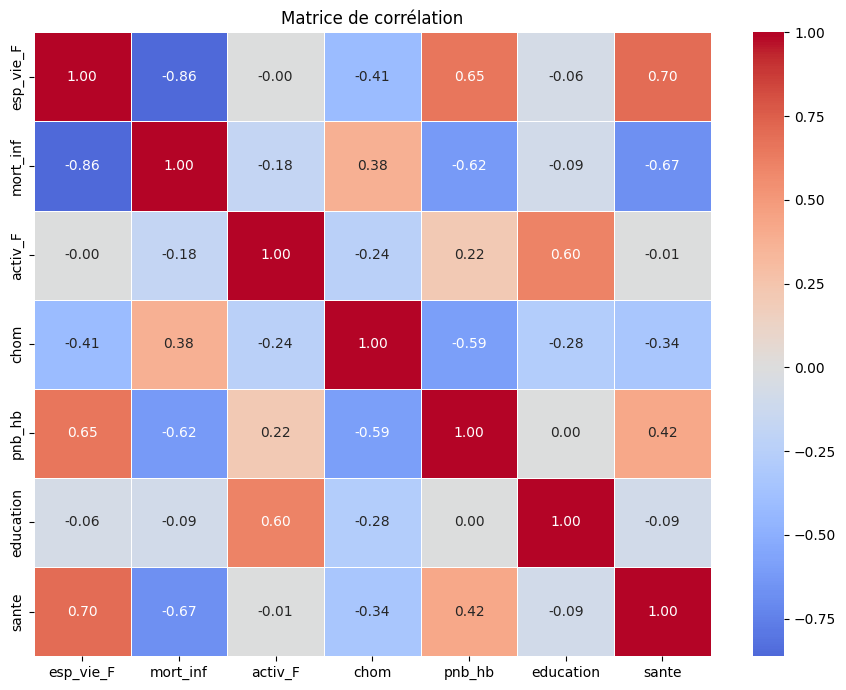

,esp_vie_F,mort_inf,activ_F,chom,pnb_hb,education,sante
esp_vie_F,1.00,-0.86,-0.00,-0.41,0.65,-0.06,0.70
mort_inf,-0.86,1.00,-0.18,0.38,-0.62,-0.09,-0.67
activ_F,-0.00,-0.18,1.00,-0.24,0.22,0.60,-0.01
chom,-0.41,0.38,-0.24,1.00,-0.59,-0.28,-0.34
pnb_hb,0.65,-0.62,0.22,-0.59,1.00,0.00,0.42
education,-0.06,-0.09,0.60,-0.28,0.00,1.00,-0.09
sante,0.70,-0.67,-0.01,-0.34,0.42,-0.09,1.00


In [10]:
corr_matrix = plot_correlation(df)
corr_matrix.round(2)

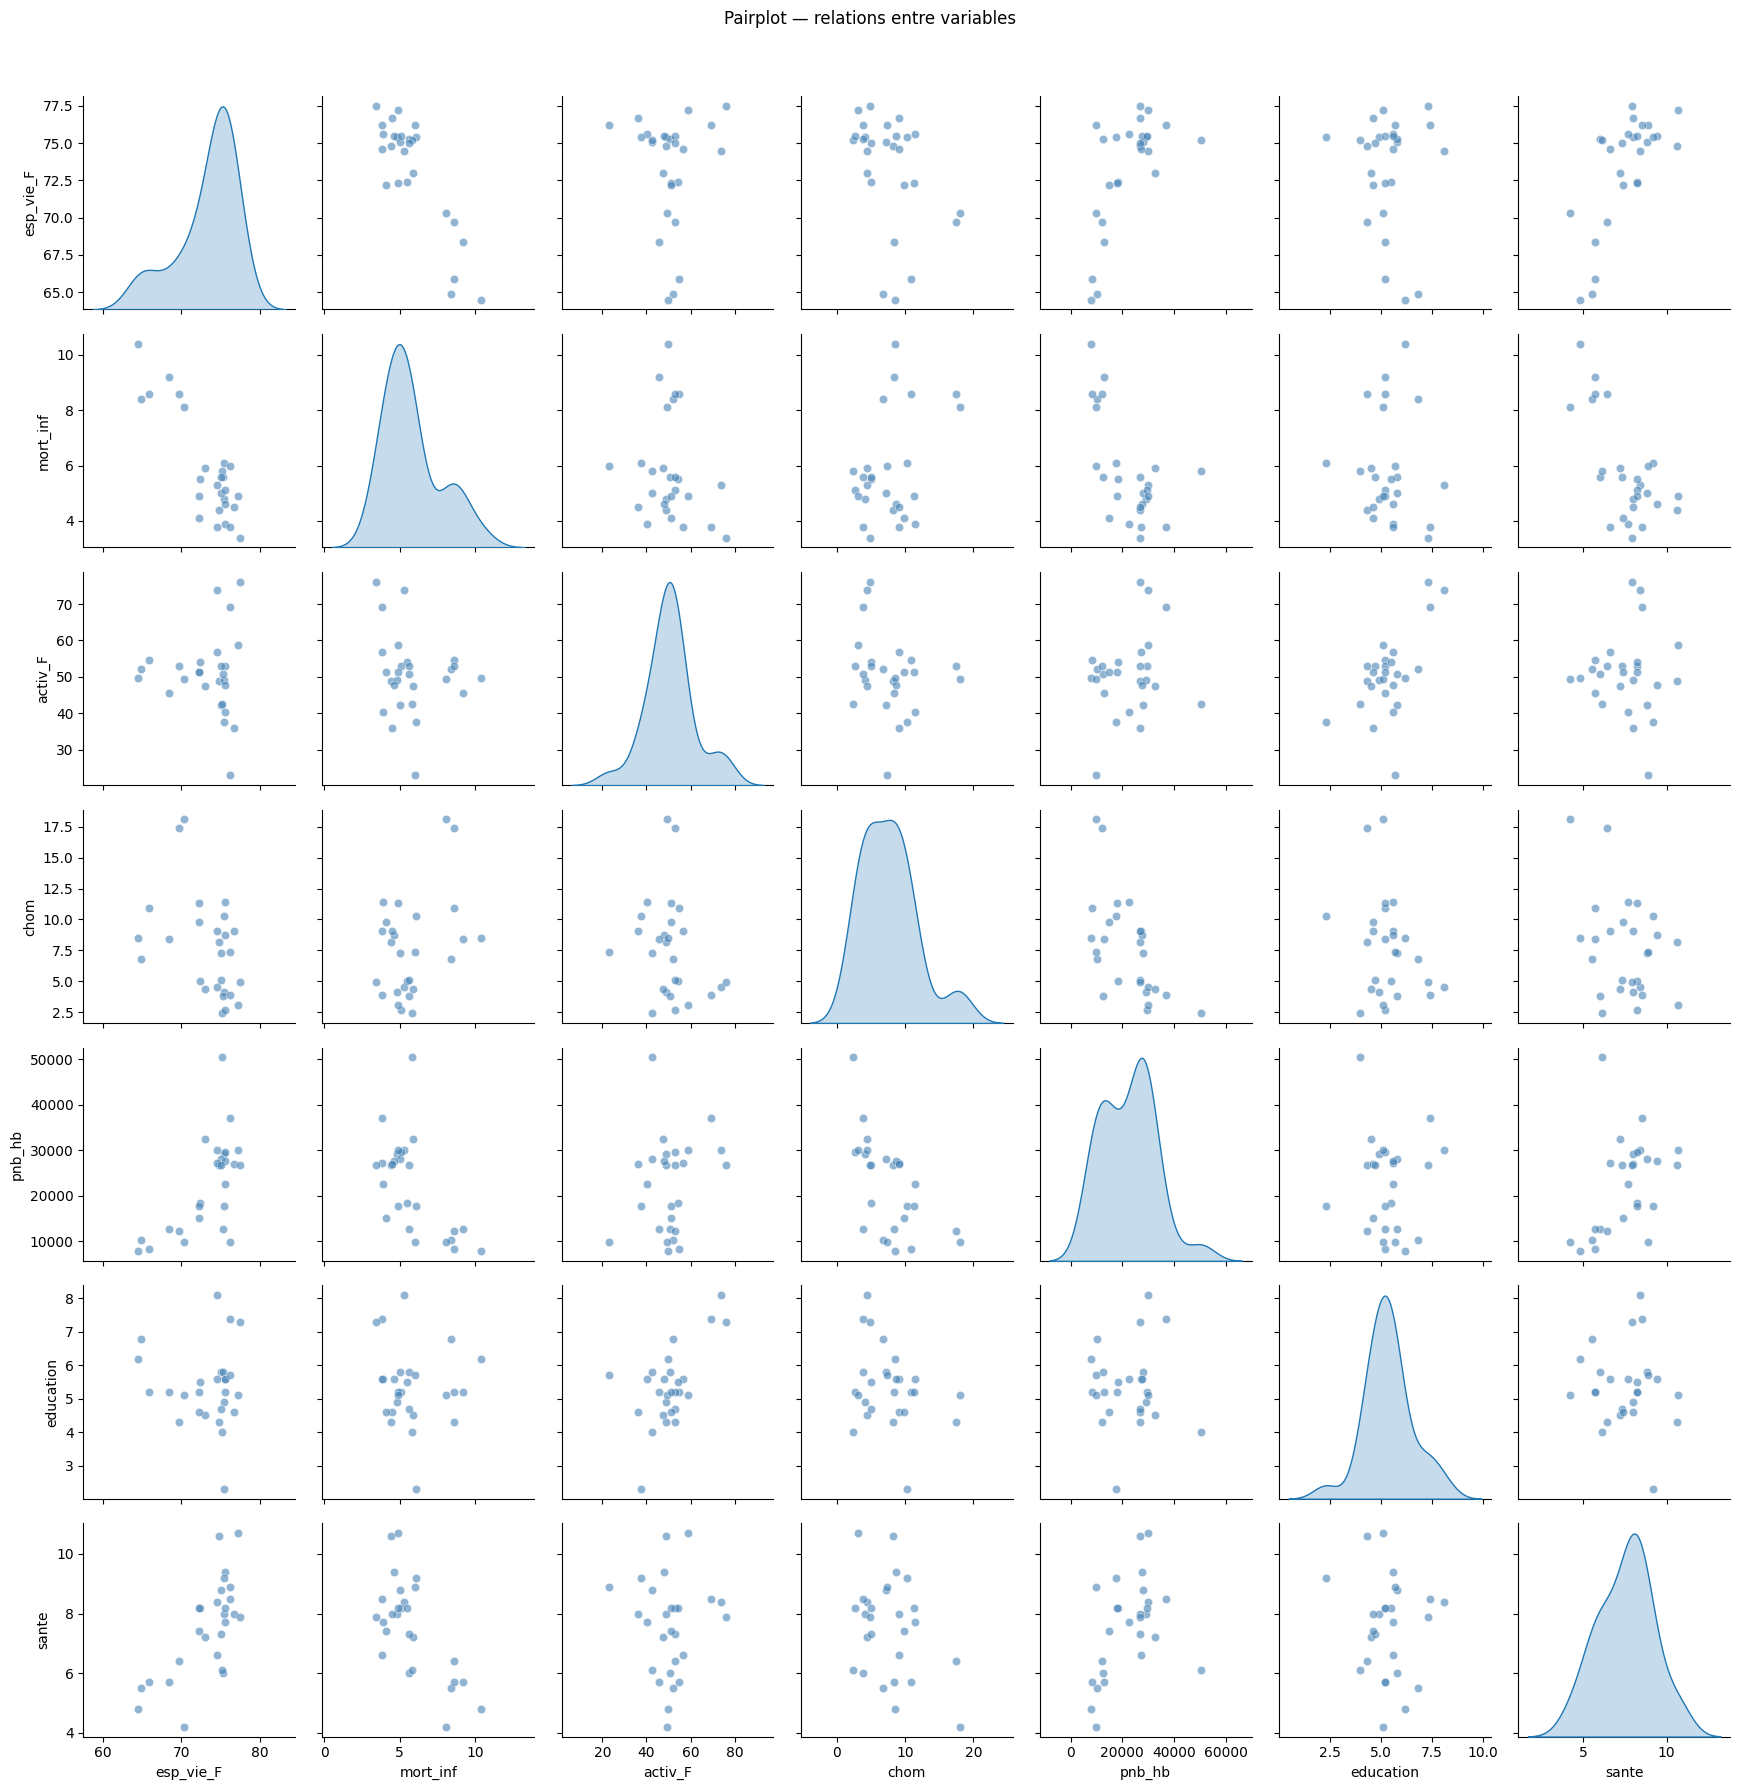

In [11]:
plot_pairplot(df)

## Interprétation de corrélation entre variables

### 1. Matrice de corrélation et Heatmap

**Corrélation forte (|r| > 0.8) :**
- `esp_vie_F` et `mort_inf` : r = **-0.86** → forte corrélation négative. Les pays avec une espérance de vie élevée ont une mortalité infantile faible, ce qui est cohérent biologiquement et socialement.

**Corrélations modérées (0.4 < |r| < 0.8) :**
- `esp_vie_F` et `sante` : r = **0.70** → les pays qui investissent davantage en santé ont une meilleure espérance de vie.
- `esp_vie_F` et `pnb_hb` : r = **0.65** → les pays plus riches ont une meilleure espérance de vie.
- `mort_inf` et `sante` : r = **-0.67** → les pays qui dépensent plus en santé ont une mortalité infantile plus faible.
- `mort_inf` et `pnb_hb` : r = **-0.62** → les pays plus riches ont une mortalité infantile plus faible.
- `activ_F` et `education` : r = **0.60** → les pays qui investissent davantage en éducation ont un taux d'activité féminine plus élevé.
- `chom` et `pnb_hb` : r = **-0.59** → les pays plus riches ont un taux de chômage plus faible.

**Corrélations nulles ou très faibles (|r| < 0.1) :**
- `activ_F` et `esp_vie_F` : r = **-0.00** → aucune relation linéaire.
- `pnb_hb` et `education` : r = **0.00** → aucune relation linéaire.
- `activ_F` et `sante` : r = **-0.01** → aucune relation linéaire.

### 2. Pairplot

Le pairplot confirme visuellement les corrélations de la matrice :
- Les nuages de points **elliptiques et allongés** correspondent aux corrélations fortes ou modérées (ex: `esp_vie_F` vs `mort_inf`).
- Les nuages de points **circulaires ou dispersés** correspondent aux corrélations nulles (ex: `activ_F` vs `sante`).
- La diagonale montre les distributions KDE de chaque variable, cohérentes avec les histogrammes vus en statistiques univariées.


La présence de corrélations significatives entre plusieurs variables confirme que les données ont une **structure multivariée** exploitable. Cela justifie le recours à l'**ACP** pour résumer cette structure en un nombre réduit de composantes principales.

## Prétraitement des données

### Normalisation 

Les variables étant hétérogènes en termes d'unités et de dispersions, nous appliquons une **normalisation (centrage-réduction)** avant l'ACP.

In [12]:
df_scaled = normalize(df)
df_scaled.round(2)

,esp_vie_F,mort_inf,activ_F,chom,pnb_hb,education,sante
pays,,,,,,,
Allemagne,0.41,-0.76,-0.17,0.14,0.43,-0.93,1.91
Autriche,0.58,-0.54,-0.15,-0.90,0.66,-0.40,0.29
Belgique,0.49,-0.43,-0.77,-0.09,0.55,0.39,0.79
Chypre,0.55,-0.10,0.02,-0.98,-0.96,0.39,-0.96
Danemark,0.33,-0.27,2.15,-0.80,0.76,2.41,0.54
Espagne,0.63,-1.03,-0.96,0.95,0.02,0.21,0.10
Estonie,-2.32,1.43,0.14,-0.22,-1.21,1.27,-1.28
Finlande,0.36,-1.09,0.57,0.37,0.48,0.21,-0.59
France,0.60,-0.65,-0.26,0.27,0.51,0.21,1.16


### Vérification de la normalisation

Après centrage-réduction, toutes les variables sont ramenées à une **moyenne nulle** et un **écart-type de 1**. Les valeurs sont désormais entre -3 et +3, ce qui les rend comparables entre elles indépendamment de leurs unités d'origine.

> **Rappel** : Après normalisation, chaque valeur devient un **z-score** : z = (x - moyenne) / écart-type. Selon la **loi normale standard**, 99.7% des valeurs se trouvent dans l'intervalle [-3, +3]. Une valeur en dehors de cet intervalle correspond donc à un point très atypique.

On peut déjà observer que les pays baltes (Estonie, Lettonie, Lituanie) ont des valeurs fortement négatives pour `esp_vie_F` et fortement positives pour `mort_inf`, confirmant leur profil atypique observé lors de l'analyse univariée.

## Analyse en Composantes Principales (ACP)

In [13]:
pca, pca2, components, variance_ratio, eigen_df, loadings_corr = run_pca(df_scaled)
eigen_df.round(2)

,Valeur propre,Variance expliquée (%),Variance cumulée (%)
PC1,3.47,47.71,47.71
PC2,1.78,24.46,72.17
PC3,0.77,10.56,82.73
PC4,0.54,7.41,90.14
PC5,0.39,5.38,95.51
PC6,0.21,2.88,98.40
PC7,0.12,1.60,100.00


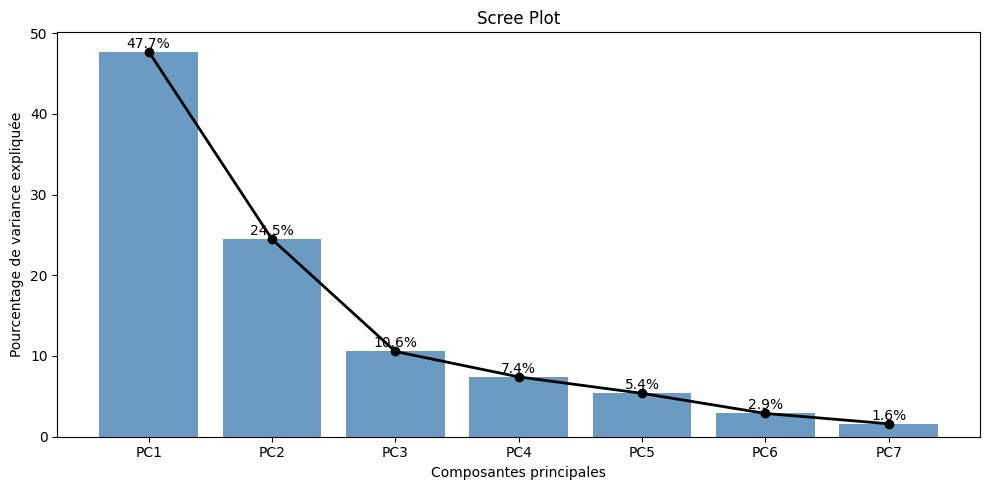

In [14]:
plot_screeplot(variance_ratio)

## Choix du nombre de composantes principales

Deux critères permettent de déterminer le nombre d'axes à retenir :

**Critère de Kaiser** : on ne retient que les composantes dont la valeur propre est **supérieure à 1**, c'est-à-dire celles qui expliquent plus de variance que n'importe quelle variable d'origine. Seules **PC1 (3.47)** et **PC2 (1.78)** satisfont ce critère, PC3 (0.77) est écartée.

**Critère du coude** : sur le scree plot, on observe un coude clair **après PC2**, la courbe chute fortement de PC1 (47.7%) à PC2 (24.5%) puis s'aplatit à partir de PC3 (10.6%).

Les deux critères convergent vers le même résultat : on retient **2 composantes principales**, qui expliquent ensemble **72.17%** de la variance totale du jeu de données.

## Contributions des variables aux PC1 et PC2

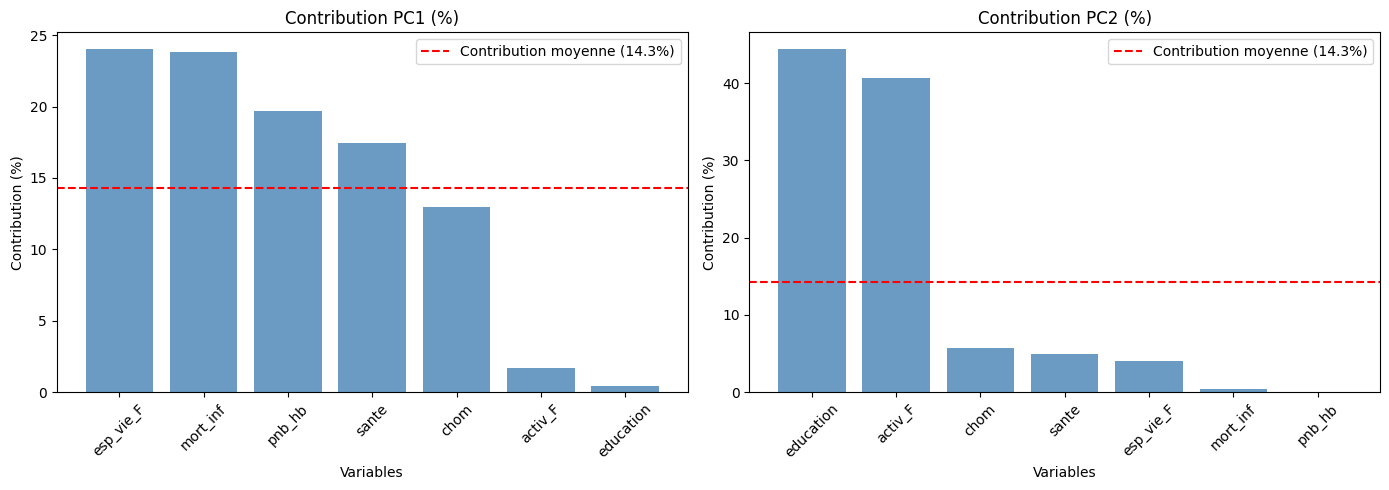

In [15]:
contributions = compute_contributions(pca2, df_scaled)
plot_contributions(contributions)

**PC1** : dominé par `esp_vie_F`, `mort_inf`, `pnb_hb` et `sante` (toutes > 14.3%).  
`activ_F` et `education` contribuent peu, donc PC1 est un axe de **développement socio-économique**.

**PC2** : dominé largement par `education` et `activ_F` (> 40% chacune).  
Les autres variables contribuent très peu, donc PC2 est un axe de **participation sociale et éducation**.


## Cercle des corrélations

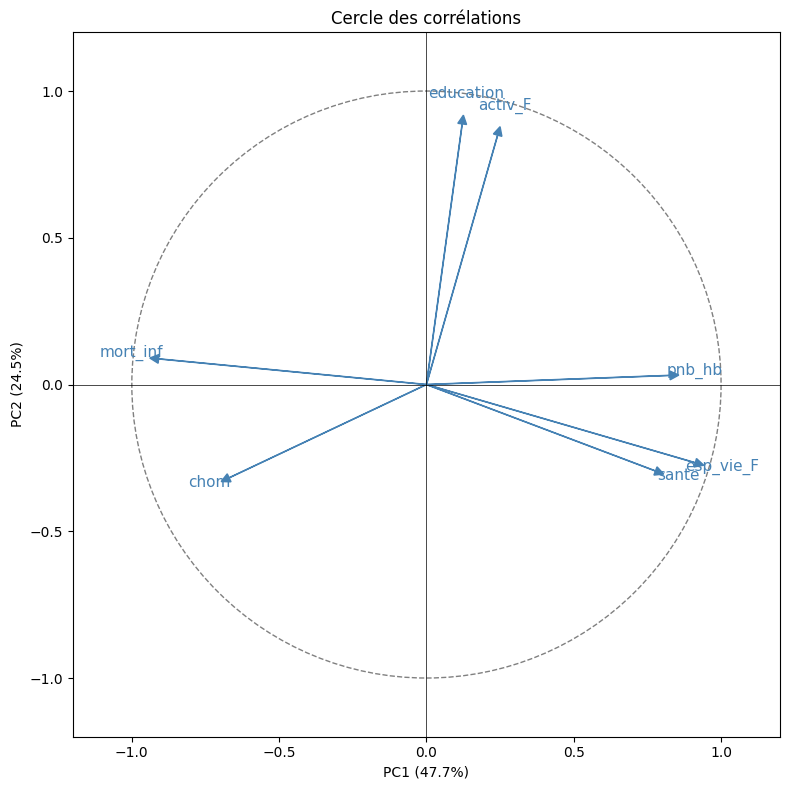

In [16]:
plot_cercle(loadings_corr, df.columns, variance_ratio)

### Interprétation du cercle des corrélations

#### PC1 (47.7%) — Axe de développement socio-économique

Le premier axe oppose deux groupes de variables :

- Côté **positif** (+) : `esp_vie_F`, `sante` et `pnb_hb` → ces variables caractérisent les pays avec une **bonne santé et une richesse élevée**.
- Côté **négatif** (-) : `mort_inf` et `chom` → ces variables caractérisent les pays avec une **mortalité infantile élevée et un chômage important**.

PC1 représente donc un **axe de développement** : les pays bien développés se situent à droite, les pays moins développés à gauche.

#### PC2 (24.5%) — Axe de participation sociale et éducation

Le deuxième axe est dominé par :

- Côté **positif** (+) : `education` et `activ_F` → les pays qui investissent dans l'éducation ont également un taux d'activité féminine élevé.

PC2 représente donc un **axe de participation sociale** indépendant du niveau de richesse.

#### Observations sur les corrélations

- `esp_vie_F` et `sante` sont très proches sur le cercle → **fortement corrélées** (r = 0.70), confirmé par la matrice de corrélation.
- `education` et `activ_F` sont très proches → **fortement corrélées** (r = 0.60).
- `mort_inf` et `esp_vie_F` sont à l'opposé sur PC1 → **anticorrélées** (r = -0.86).
- `pnb_hb` est proche de la circonférence → **bien représenté** sur PC1.

## Plan factoriel des individus

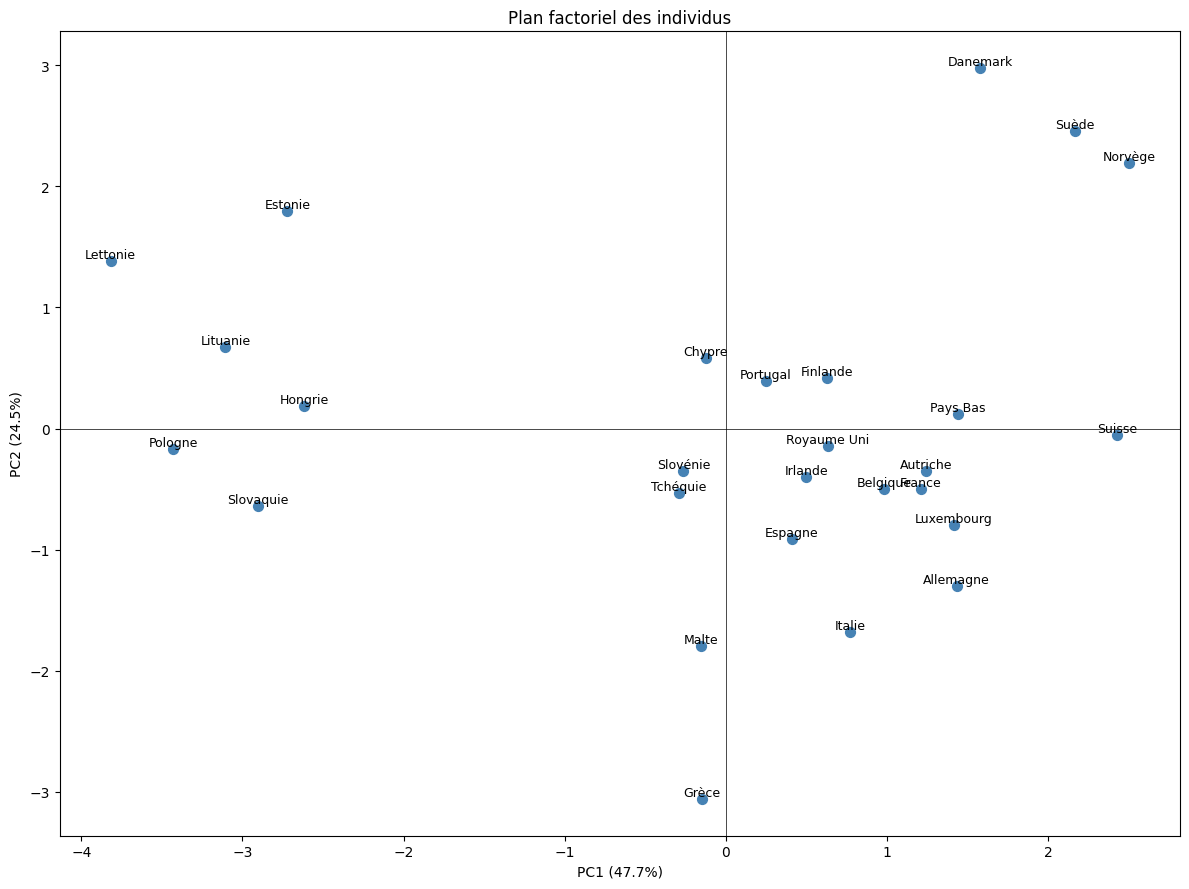

In [17]:
plot_plan_factoriel(components, df.index, variance_ratio)

### Interprétation du plan factoriel des individus

#### Lecture du plan

Le plan factoriel confirme les interprétations du cercle des corrélations :

**Sur PC1 (axe horizontal — développement socio-économique) :**
- Les pays situés à **gauche** (valeurs négatives) : Lettonie, Estonie, Lituanie, Pologne, Slovaquie, Hongrie → pays d'**Europe de l'Est**, caractérisés par une mortalité infantile élevée, un chômage important et un PNB faible.
- Les pays situés à **droite** (valeurs positives) : Norvège, Suède, Danemark, Suisse, Luxembourg → pays d'**Europe du Nord/Ouest**, caractérisés par une espérance de vie élevée, de bonnes dépenses de santé et un PNB élevé.

**Sur PC2 (axe vertical — participation sociale et éducation) :**
- Les pays situés en **haut** : Danemark, Suède, Norvège, Estonie → fort investissement en éducation et taux d'activité féminine élevé.
- Les pays situés en **bas** : Grèce, Malte, Italie, Allemagne → faible taux d'activité féminine.

#### Groupes naturels observés

On distingue visuellement **3 groupes** dans le plan factoriel :
- Un groupe **Europe de l'Est** (gauche du plan)
- Un groupe **Europe du Nord** (droite haut)
- Un groupe **Europe du Sud/Ouest** (bas du plan)

## Classification Hiérarchique Ascendante (CAH)

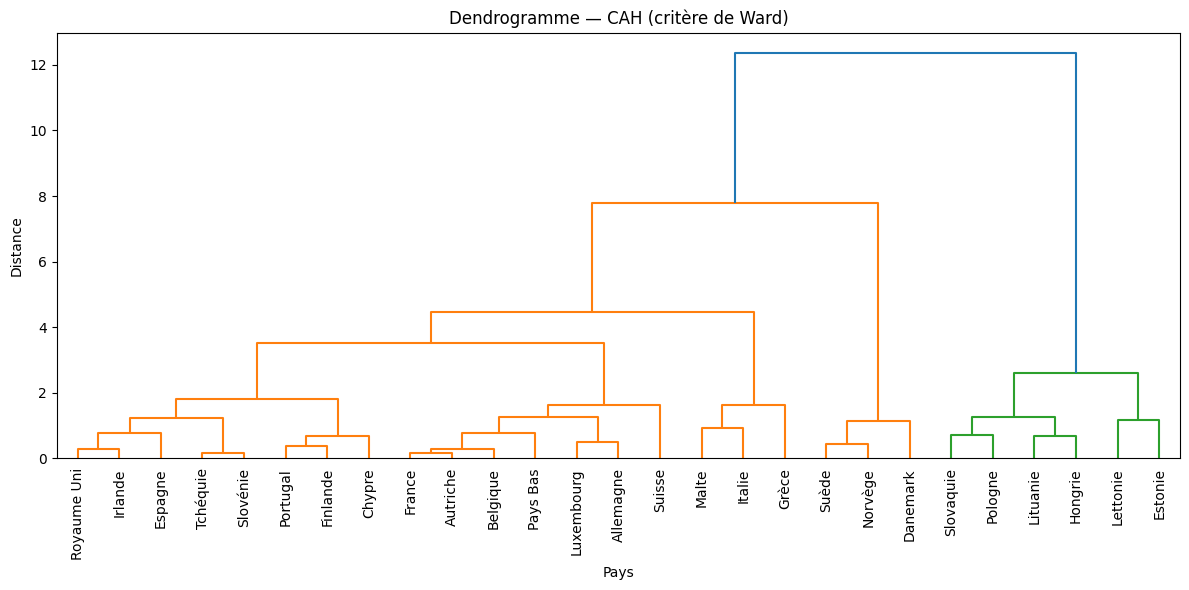

In [18]:
linked = run_cah(components, df.index)

### Interprétation du dendrogramme

La CAH est appliquée sur les **2 composantes principales** retenues lors de l'ACP, en utilisant le **critère de Ward**, le plus adapté pour des données appliquées sur des composantes principales.

En coupant le dendrogramme à une distance d'environ **5**, on obtient **3 groupes distincts**


- **Groupe 1 : Europe de l'Est** : Slovaquie, Pologne, Lituanie, Hongrie, Lettonie, Estonie
- **Groupe 2 : Europe du Nord** : Danemark, Norvège, Suède
- **Groupe 3 : Europe du Sud/Ouest** : Grèce, Malte, Italie, Espagne, Portugal, France, Belgique, Allemagne, Luxembourg, Suisse...

Ce résultat est cohérent avec les groupes observés visuellement dans le plan factoriel de l'ACP. La CAH suggère donc **k = 3** comme nombre optimal de clusters.

Nous allons confirmer ce choix avec le **score de silhouette**.

## K-means Clustering

### Score de silhouette pour choisir k optimal

In [19]:
silhouette_scores = compute_silhouette(components, k_range=range(2, 6))

k=2 : silhouette = 0.572
k=3 : silhouette = 0.603
k=4 : silhouette = 0.488
k=5 : silhouette = 0.472


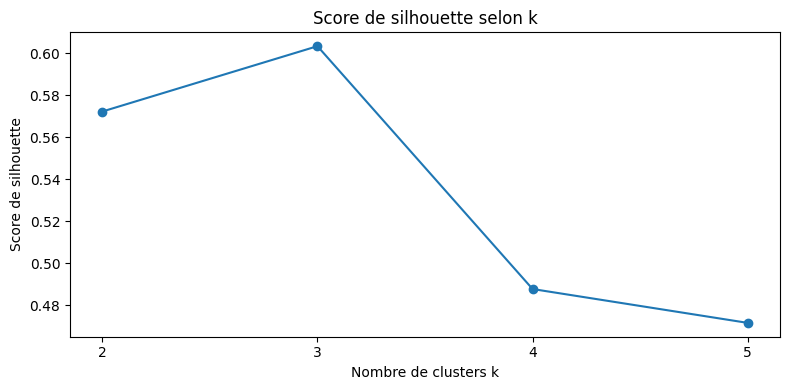

In [20]:
plot_silhouette(silhouette_scores)

Le graphe de la silhouette montre que le score le plus élevé est obtenu pour **k=3** (score = 0.603), ce qui confirme le résultat suggéré par le dendrogramme de la CAH. Les deux méthodes convergent vers **k=3** comme nombre optimal de clusters.

### Appliquer K-means final avec le nombre optimal de clusters (k)

In [21]:
df["cluster"] = run_kmeans(components, k=3)
df["cluster"].value_counts()

cluster
1    18
0     6
2     3
Name: count, dtype: int64

In [22]:
for i in range(3):
    pays = df[df["cluster"] == i].index.tolist()
    print(f"\nCluster {i} : {pays}")



Cluster 0 : ['Estonie', 'Hongrie', 'Lettonie', 'Lituanie', 'Pologne', 'Slovaquie']

Cluster 1 : ['Allemagne', 'Autriche', 'Belgique', 'Chypre', 'Espagne', 'Finlande', 'France', 'Grèce', 'Irlande', 'Italie', 'Luxembourg', 'Malte', 'Pays Bas', 'Portugal', 'Royaume Uni', 'Slovénie', 'Suisse', 'Tchéquie']

Cluster 2 : ['Danemark', 'Norvège', 'Suède']


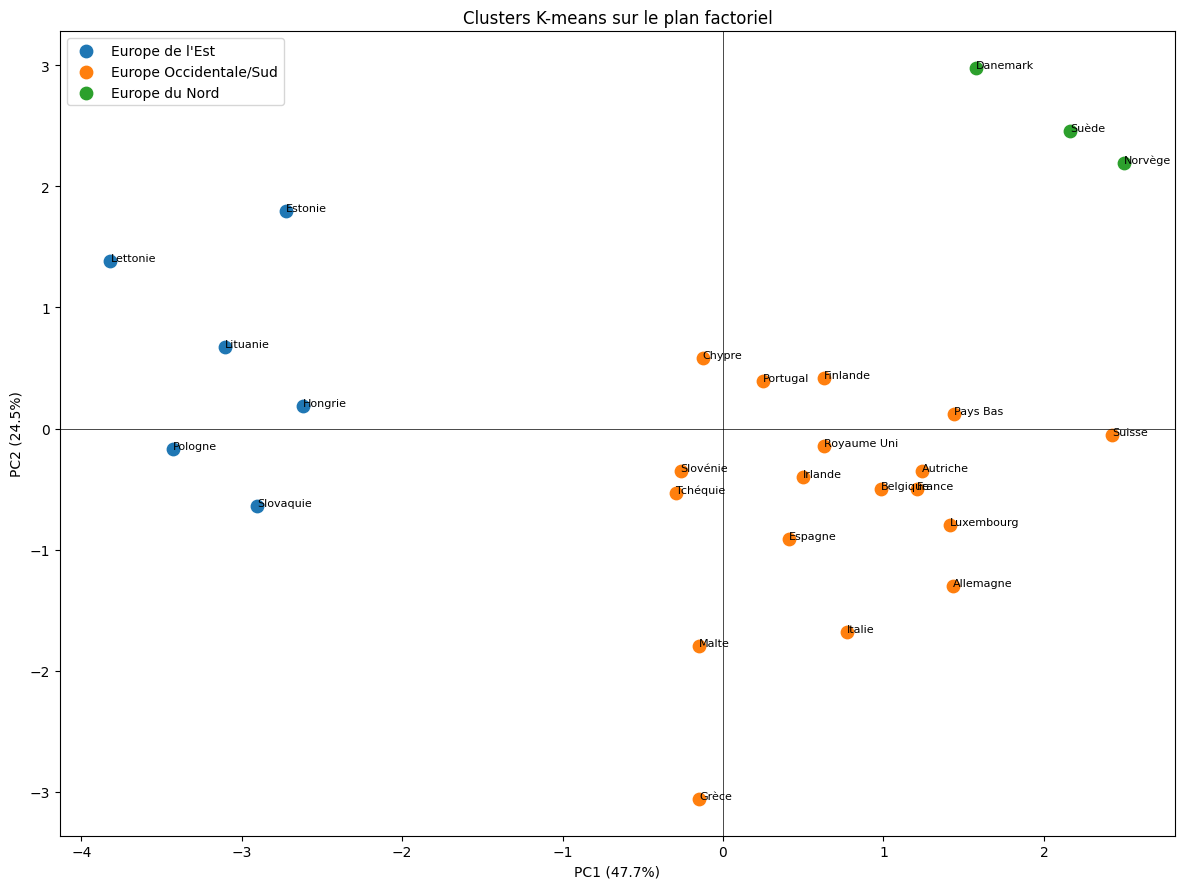

In [23]:
labels_name = ["Europe de l'Est", "Europe Occidentale/Sud", "Europe du Nord"]
plot_clusters(components, df, variance_ratio, labels_name)

In [24]:
df.groupby("cluster").mean().round(2)

,esp_vie_F,mort_inf,activ_F,chom,pnb_hb,education,sante
cluster,,,,,,,
0,67.28,8.88,50.75,11.68,10211.33,5.47,5.38
1,74.86,5.03,46.88,6.84,24943.50,4.94,8.14
2,76.07,4.17,73.07,4.43,31338.33,7.60,8.27


### Interprétation des clusters

**Cluster 0 — Europe de l'Est** (Estonie, Hongrie, Lettonie, Lituanie, Pologne, Slovaquie) :
- Espérance de vie faible (67.3 ans), mortalité infantile élevée (8.9‰)
- Chômage élevé (11.7%) et PNB faible (10 211 $)
- Profil : pays **peu développés économiquement**

**Cluster 1 — Europe Occidentale/Sud** (Allemagne, France, Belgique, Italie, Espagne...) :
- Espérance de vie élevée (74.9 ans), mortalité infantile modérée (5.0‰)
- PNB moyen (24 944 $), faible activité féminine (46.9%)
- Profil : pays **développés à participation féminine modérée**

**Cluster 2 — Europe du Nord** (Danemark, Norvège, Suède) :
- Meilleure espérance de vie (76.1 ans), mortalité infantile la plus faible (4.2‰)
- Fort taux d'activité féminine (73.1%), PNB élevé (31 338 $), dépenses éducation élevées (7.6%)
- Profil : pays **très développés avec forte égalité de genre**


# Conclusion

Ce projet avait pour objectif d'analyser et de classifier 27 pays européens à partir de 7 indicateurs socio-économiques de l'année 2001, en utilisant des méthodes d'apprentissage non supervisé.

## Démarche suivie

1. **Analyse exploratoire (EDA)** : l'analyse univariée et bivariée a révélé une forte hétérogénéité des données, notamment entre les pays d'Europe de l'Est et les pays d'Europe du Nord/Ouest. Plusieurs outliers ont été détectés (pays baltes, pays scandinaves) mais conservés car reflétant la réalité socio-économique.

2. **Prétraitement** : une normalisation (centrage-réduction) a été appliquée pour corriger la disparité des unités et des dispersions entre les variables.

3. **ACP normée** : les deux premières composantes principales ont été retenues (critère de Kaiser + coude), expliquant **72.17%** de la variance totale. PC1 représente un axe de **développement socio-économique**, PC2 un axe de **participation sociale et éducation**.

4. **Clustering** : la CAH et la silhouette ont convergé vers **k=3** comme nombre optimal de clusters, confirmé par un score de silhouette de **0.603**.

## Résultats

Le K-means a identifié **3 groupes distincts** de pays européens :

- **Europe de l'Est** (6 pays) : pays peu développés économiquement, avec une mortalité infantile élevée et un PNB faible.
- **Europe Occidentale/Sud** (18 pays) : pays développés avec un profil intermédiaire.
- **Europe du Nord** (3 pays) : pays très développés, avec une forte égalité de genre et un investissement élevé en éducation.

Ces résultats reflètent les disparités économiques et sociales qui existaient en Europe en 2001.